# 1. Libraries

In [17]:
import joblib
import pandas as pd
from pyglam import GlamFKML
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# 2. Upload ML model

In [8]:
try:
    mlp_l1 = joblib.load("model_mlp_lambda1.pkl")
    mlp_l2 = joblib.load("model_mlp_lambda2.pkl")
    scaler = joblib.load("scaler.pkl")
    print("Model load sucessfully")
except FileNotFoundError:
    print("Error")

Model load sucessfully


# 3. Use ML model

Predict values of $\lambda_1$ and $\lambda_ 2$.

In [11]:
# Concrete beam properties
fck_input   = 30.0
rh_input    = 65.0
cover_input = 40.0

# time steps
lista_tempos = [0.0, 16.666666666666668, 33.333333333333336, 50.0, 66.66666666666667, 83.33333333333334, 100.0, 116.66666666666667, 133.33333333333334, 150.0]

# Cria um DataFrame repetindo as condições fixas para cada tempo da lista
novos_dados = pd.DataFrame({
                                "fck_mpa": [fck_input] * len(lista_tempos),
                                "rh_percent": [rh_input] * len(lista_tempos),
                                "cover_mm": [cover_input] * len(lista_tempos),
                                "tempo": lista_tempos
                            })

print(f"\nRealizando predições para Fck={fck_input}MPa, RH={rh_input}%, Cobrimento={cover_input}mm...\n")

# Escalonar os novos dados e fazer as predições

X_novos_escalonados = scaler.transform(novos_dados)

# Fazemos as predições separadas
novos_dados["pred_lambda_1"] = mlp_l1.predict(X_novos_escalonados)
novos_dados["pred_lambda_2"] = mlp_l2.predict(X_novos_escalonados)
novos_dados["pred_lambda_3"] = 0.13
novos_dados["pred_lambda_4"] = 0.12

# O dataframe agora devolve a relação completa do tempo vs lambdas
novos_dados


Realizando predições para Fck=30.0MPa, RH=65.0%, Cobrimento=40.0mm...



c:\git-projetos\2024-1_victor_hugo_renata_maria\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,fck_mpa,rh_percent,cover_mm,tempo,pred_lambda_1,pred_lambda_2,pred_lambda_3,pred_lambda_4
0,30.0,65.0,40.0,0.000000,39.599110,1.798032,0.13,0.12
1,30.0,65.0,40.0,16.666667,27.423679,1.626900,0.13,0.12
2,30.0,65.0,40.0,33.333333,22.786891,1.450434,0.13,0.12
3,30.0,65.0,40.0,50.000000,18.330571,1.320767,0.13,0.12
4,30.0,65.0,40.0,66.666667,14.943080,1.237512,0.13,0.12
5,30.0,65.0,40.0,83.333333,12.195621,1.161478,0.13,0.12
6,30.0,65.0,40.0,100.000000,9.524363,1.080813,0.13,0.12
7,30.0,65.0,40.0,116.666667,6.974053,1.002097,0.13,0.12
8,30.0,65.0,40.0,133.333333,4.467524,0.931302,0.13,0.12
9,30.0,65.0,40.0,150.000000,2.190534,0.869596,0.13,0.12


# 4. Use Pyglam model

In [21]:
# data_unique = joblib.load("100000_dataset_unique_0.0_install_1990_cement_3_exposure_2.pkl")
# data_unique
lambda_1_ti = novos_dados["pred_lambda_1"].values[9]
lambda_2_ti = novos_dados["pred_lambda_2"].values[9]
lambda_3_ti = novos_dados["pred_lambda_3"].values[9]
lambda_4_ti = novos_dados["pred_lambda_4"].values[9]
g_emulator_obj = GlamFKML(lam1=lambda_1_ti, lam2=lambda_2_ti, lam3=lambda_3_ti, lam4=lambda_4_ti)
samples_g_ti   = g_emulator_obj.rvs(size=1000)
samples_g_ti

array([-3.05053322e+00, -2.70984087e+00, -2.49535848e+00, -2.33586230e+00,
       -2.20773705e+00, -2.10006597e+00, -2.00685897e+00, -1.92445761e+00,
       -1.85045599e+00, -1.78318358e+00, -1.72143108e+00, -1.66429368e+00,
       -1.61107591e+00, -1.56123123e+00, -1.51432195e+00, -1.46999189e+00,
       -1.42794719e+00, -1.38794238e+00, -1.34977027e+00, -1.31325431e+00,
       -1.27824274e+00, -1.24460415e+00, -1.21222396e+00, -1.18100161e+00,
       -1.15084837e+00, -1.12168554e+00, -1.09344294e+00, -1.06605777e+00,
       -1.03947353e+00, -1.01363927e+00, -9.88508826e-01, -9.64040249e-01,
       -9.40195309e-01, -9.16939056e-01, -8.94239455e-01, -8.72067065e-01,
       -8.50394765e-01, -8.29197514e-01, -8.08452139e-01, -7.88137157e-01,
       -7.68232607e-01, -7.48719912e-01, -7.29581753e-01, -7.10801951e-01,
       -6.92365378e-01, -6.74257856e-01, -6.56466087e-01, -6.38977576e-01,
       -6.21780569e-01, -6.04863993e-01, -5.88217408e-01, -5.71830953e-01,
       -5.55695308e-01, -

(array([0.00563921, 0.00281961, 0.01127843, 0.01409803, 0.02537646,
        0.03383528, 0.05357253, 0.07330978, 0.09586664, 0.12688231,
        0.15789799, 0.18327445, 0.21147052, 0.22838816, 0.23684698,
        0.23402737, 0.21992934, 0.20019209, 0.17199602, 0.14379995,
        0.11278428, 0.08458821, 0.06485096, 0.04511371, 0.03101568,
        0.01973725, 0.01409803, 0.00845882, 0.00563921, 0.00281961]),
 array([-3.05053322, -2.69587386, -2.34121449, -1.98655513, -1.63189576,
        -1.2772364 , -0.92257703, -0.56791767, -0.2132583 ,  0.14140106,
         0.49606043,  0.85071979,  1.20537916,  1.56003852,  1.91469789,
         2.26935725,  2.62401662,  2.97867598,  3.33333535,  3.68799471,
         4.04265408,  4.39731344,  4.75197281,  5.10663217,  5.46129154,
         5.8159509 ,  6.17061027,  6.52526963,  6.879929  ,  7.23458836,
         7.58924773]),
 <BarContainer object of 30 artists>)

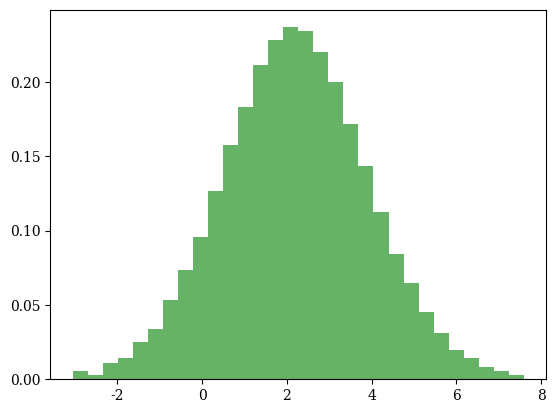

In [22]:
plt.hist(samples_g_ti, bins=30, density=True, alpha=0.6, color='g')